In [6]:

import sys
import os
import time
import numpy as np

import MDAnalysis as mda
# from MDAnalysis.analysis import align
# from MDAnalysis.analysis import distances

import westpa
from westpa.analysis import Run

import matplotlib.pyplot as plt

In [7]:
#this barely needs to be a method but having the .h5 stuff compartmentalized is nice
def load_h5_pcs(h5path, miniter, maxiter):
    
    run = Run.open(h5path)

    #set maximum iteration automatically
    if maxiter == -1:
        maxiter = run.num_iterations

    pcs = [iteration.pcoords for iteration in run if (iteration.number >= miniter and iteration.number < maxiter)]

    return pcs

In [8]:
#specify input file

cftr_west = "/home/jonathan/Documents/grabelab/cftr/chloe-data"
cftr_refpc = "/home/jonathan/Documents/grabelab/cftr/refeaturization"

h5paths_names = [[f"{cftr_west}/wstp_cftr_1_degrabo/west-040925.h5", f"{cftr_refpc}/nonlip_glpg_1", "pyrazole-1", "blue"],
                  [f"{cftr_west}/wstp_cftr_2_wynton/west-040925.h5", f"{cftr_refpc}/nonlip_glpg_2", "pyrazole-2", "cyan"],
                  [f"{cftr_west}/wstp_lip_glpg_1/west-040925.h5", f"{cftr_refpc}/lip_glpg_1", "undecanol-1", "red"],
                  [f"{cftr_west}/wstp_lip_glpg_2/west-040925.h5", f"{cftr_refpc}/lip_glpg_2", "undecanol-2", "orange"]]

#westpa rounds to load
minround = 0
maxround = -1

run_ind = 3

data_paths = ["/home/jonathan/Documents/grabelab/cftr/revisions/abbv-974-1",
              "/home/jonathan/Documents/grabelab/cftr/revisions/abbv-974-2",
              "/home/jonathan/Documents/grabelab/cftr/revisions/cftri-c10-1",
              "/home/jonathan/Documents/grabelab/cftr/revisions/cftri-c10-2"]
data_path = data_paths[run_ind]

In [9]:
pcs_all = load_h5_pcs(h5paths_names[run_ind][0], minround, maxround)

In [10]:
nbins = 51
binbounds = np.arange(0,nbins,1)
bincenters = [(binbounds[i]+binbounds[i+1])/2 for i in range(len(binbounds)-1)]
lig_saltbridge_hbonds_by_bin = [[] for a in range(nbins)]
#membrane_thickness_by_bin = [[] for a in range(nbins)]

#later init_round values avoid questions about confounding time correlations but increase statistical noise
init_round = 0
final_round = 2000
#loop over WE rounds
for r in range(init_round+1,final_round,10):
    
    #get progress coordinates of the walkers, accounting for the occasional corrupted file
    pcs_flat = pcs_all[r-1][:,-1].flatten()
    walkers = np.load(f"{data_path}/pc_data_round_{r}_walker_numbers_v1.npy")
    pcs = [pcs_flat[w] for w in walkers]

    #assign frames to bins by pc
    bins = np.digitize(pcs, binbounds)

    #load water coordinates
    lig_saltbridge_hbonds = np.load(f"{data_path}/pc_data_round_{r}_lig_saltbridge_hbonds_v1.npy")
    #membrane_thickness = np.load(f"{data_path}/pc_data_round_{r}_membrane_thickness_v1.npy")

    #get coordinates of waters in each bin
    for b, salt in zip(bins, lig_saltbridge_hbonds):
        lig_saltbridge_hbonds_by_bin[b].append(salt)

for i, w in enumerate(lig_saltbridge_hbonds):
    print(f"{i}: {len(w)}")

mean_lig_saltbridge_hbonds_by_bin = np.stack([np.mean(w, axis = 0) if len(w) > 0 else -np.ones(2) for w in lig_saltbridge_hbonds_by_bin])
std_lig_saltbridge_hbonds_by_bin = np.stack([np.std(w, axis = 0) if len(w) > 0 else np.zeros(2) for w in lig_saltbridge_hbonds_by_bin])

0: 2
1: 2
2: 2
3: 2
4: 2
5: 2
6: 2
7: 2
8: 2
9: 2
10: 2
11: 2
12: 2
13: 2
14: 2
15: 2
16: 2
17: 2
18: 2
19: 2
20: 2
21: 2
22: 2
23: 2
24: 2
25: 2
26: 2
27: 2
28: 2
29: 2
30: 2
31: 2
32: 2
33: 2
34: 2
35: 2
36: 2
37: 2
38: 2
39: 2
40: 2
41: 2
42: 2
43: 2
44: 2
45: 2
46: 2
47: 2
48: 2
49: 2
50: 2
51: 2
52: 2
53: 2
54: 2
55: 2
56: 2
57: 2
58: 2
59: 2
60: 2
61: 2
62: 2
63: 2
64: 2
65: 2
66: 2
67: 2
68: 2
69: 2
70: 2
71: 2
72: 2
73: 2
74: 2
75: 2
76: 2
77: 2
78: 2
79: 2
80: 2
81: 2
82: 2
83: 2
84: 2
85: 2
86: 2
87: 2
88: 2
89: 2
90: 2
91: 2
92: 2
93: 2
94: 2
95: 2
96: 2
97: 2
98: 2
99: 2
100: 2
101: 2
102: 2
103: 2
104: 2
105: 2
106: 2
107: 2
108: 2
109: 2
110: 2
111: 2
112: 2
113: 2
114: 2
115: 2
116: 2
117: 2
118: 2
119: 2
120: 2
121: 2
122: 2
123: 2
124: 2
125: 2
126: 2
127: 2
128: 2
129: 2
130: 2
131: 2
132: 2
133: 2
134: 2
135: 2
136: 2
137: 2
138: 2
139: 2
140: 2
141: 2
142: 2
143: 2
144: 2
145: 2
146: 2
147: 2
148: 2
149: 2
150: 2
151: 2
152: 2
153: 2
154: 2
155: 2
156: 2
157: 2
158:

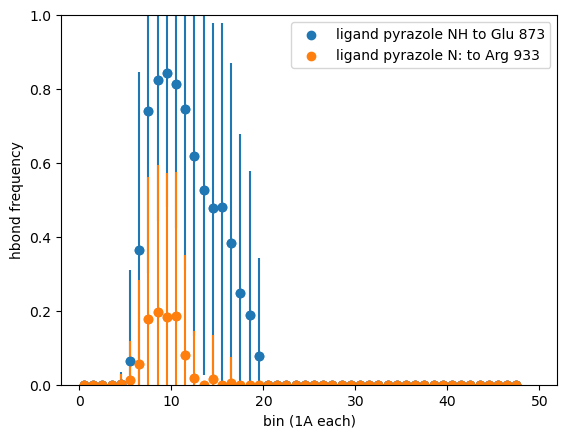

In [11]:
plt.scatter(bincenters, mean_lig_saltbridge_hbonds_by_bin[1:,0], label = "ligand pyrazole NH to Glu 873")
plt.errorbar(bincenters, mean_lig_saltbridge_hbonds_by_bin[1:,0], yerr=std_lig_saltbridge_hbonds_by_bin[1:,0], fmt = "o", label="_nolabel_")
plt.scatter(bincenters, mean_lig_saltbridge_hbonds_by_bin[1:,1], label = "ligand pyrazole N: to Arg 933")
plt.errorbar(bincenters, mean_lig_saltbridge_hbonds_by_bin[1:,1], yerr=std_lig_saltbridge_hbonds_by_bin[1:,1], fmt = "o", label="_nolabel_")
plt.xlabel("bin (1A each)")
plt.ylabel("hbond frequency")
plt.ylim(0,1)
plt.legend()

In [52]:
def plot_to_subplot(data_path, h5path, final_round, axs, splt, labels):

    pcs_all = load_h5_pcs(h5path, minround, maxround)

    nbins = 51
    binbounds = np.arange(0,nbins,1)
    bincenters = [(binbounds[i]+binbounds[i+1])/2 for i in range(len(binbounds)-1)]
    lig_saltbridge_hbonds_by_bin = [[] for a in range(nbins)]
    #membrane_thickness_by_bin = [[] for a in range(nbins)]

    #later init_round values avoid questions about confounding time correlations but increase statistical noise
    init_round = 0
    #final_round = 2000
    #loop over WE rounds
    for r in range(init_round+1,final_round,10):
        
        #get progress coordinates of the walkers, accounting for the occasional corrupted file
        pcs_flat = pcs_all[r-1][:,-1].flatten()
        walkers = np.load(f"{data_path}/pc_data_round_{r}_walker_numbers_v1.npy")
        pcs = [pcs_flat[w] for w in walkers]

        #assign frames to bins by pc
        bins = np.digitize(pcs, binbounds)

        #load water coordinates
        lig_saltbridge_hbonds = np.load(f"{data_path}/pc_data_round_{r}_lig_saltbridge_hbonds_v1.npy")
        #membrane_thickness = np.load(f"{data_path}/pc_data_round_{r}_membrane_thickness_v1.npy")

        #get coordinates of waters in each bin
        for b, salt in zip(bins, lig_saltbridge_hbonds):
            lig_saltbridge_hbonds_by_bin[b].append(salt)

    for i, w in enumerate(lig_saltbridge_hbonds):
        print(f"{i}: {len(w)}")

    mean_lig_saltbridge_hbonds_by_bin = np.stack([np.mean(w, axis = 0) if len(w) > 0 else -np.ones(2) for w in lig_saltbridge_hbonds_by_bin])
    std_lig_saltbridge_hbonds_by_bin = np.stack([np.std(w, axis = 0) if len(w) > 0 else np.zeros(2) for w in lig_saltbridge_hbonds_by_bin])

    axs[splt].scatter(bincenters, mean_lig_saltbridge_hbonds_by_bin[1:,0], label = labels[0], alpha = 0.4)
    axs[splt].errorbar(bincenters, mean_lig_saltbridge_hbonds_by_bin[1:,0], yerr=std_lig_saltbridge_hbonds_by_bin[1:,0], fmt = "o", label="_nolabel_", alpha = 0.4)
    axs[splt].scatter(bincenters, mean_lig_saltbridge_hbonds_by_bin[1:,1], label = labels[1], alpha = 0.4)
    axs[splt].errorbar(bincenters, mean_lig_saltbridge_hbonds_by_bin[1:,1], yerr=std_lig_saltbridge_hbonds_by_bin[1:,1], fmt = "o", label="_nolabel_", alpha = 0.4)
    # plt.xlabel("bin (1A each)")
    # plt.ylabel("hbond frequency")
    axs[splt].set_xlim(0,40)
    axs[splt].set_ylim(0,1)

    title_elements = data_path.split("/")[-1].split("-")
    if title_elements[0] == "abbv":
        ti0 = "ABBV"
    elif title_elements[0] == "cftri":
        ti0 = "CFTRi"
        
    axs[splt].set_title(f"{ti0}-{title_elements[1].upper()} run {title_elements[2]}")

    if splt[1] == 0:
        axs[splt].set_ylabel("hydrogen bond frequency (dimensionless)")
    if splt[0] == 1:
        axs[splt].set_xlabel(r"ligand distance from bound pose ($\AA$)")

    axs[splt].legend()

0: 2
1: 2
2: 2
3: 2
4: 2
5: 2
6: 2
7: 2
8: 2
9: 2
10: 2
11: 2
12: 2
13: 2
14: 2
15: 2
16: 2
17: 2
18: 2
19: 2
20: 2
21: 2
22: 2
23: 2
24: 2
25: 2
26: 2
27: 2
28: 2
29: 2
30: 2
31: 2
32: 2
33: 2
34: 2
35: 2
36: 2
37: 2
38: 2
39: 2
40: 2
41: 2
42: 2
43: 2
44: 2
45: 2
46: 2
47: 2
48: 2
49: 2
50: 2
51: 2
52: 2
53: 2
54: 2
55: 2
56: 2
57: 2
58: 2
59: 2
60: 2
61: 2
62: 2
63: 2
64: 2
65: 2
66: 2
67: 2
68: 2
69: 2
70: 2
71: 2
72: 2
73: 2
74: 2
75: 2
76: 2
77: 2
78: 2
79: 2
80: 2
81: 2
82: 2
83: 2
84: 2
85: 2
86: 2
87: 2
88: 2
89: 2
90: 2
91: 2
92: 2
93: 2
94: 2
95: 2
96: 2
97: 2
98: 2
99: 2
100: 2
101: 2
102: 2
103: 2
104: 2
105: 2
106: 2
107: 2
108: 2
109: 2
110: 2
111: 2
112: 2
113: 2
114: 2
115: 2
116: 2
117: 2
118: 2
119: 2
120: 2
121: 2
122: 2
123: 2
124: 2
125: 2
126: 2
127: 2
128: 2
129: 2
130: 2
131: 2
132: 2
133: 2
134: 2
135: 2
136: 2
137: 2
138: 2
139: 2
140: 2
141: 2
142: 2
143: 2
144: 2
145: 2
146: 2
147: 2
148: 2
149: 2
150: 2
151: 2
152: 2
153: 2
154: 2
155: 2
156: 2
157: 2
158:

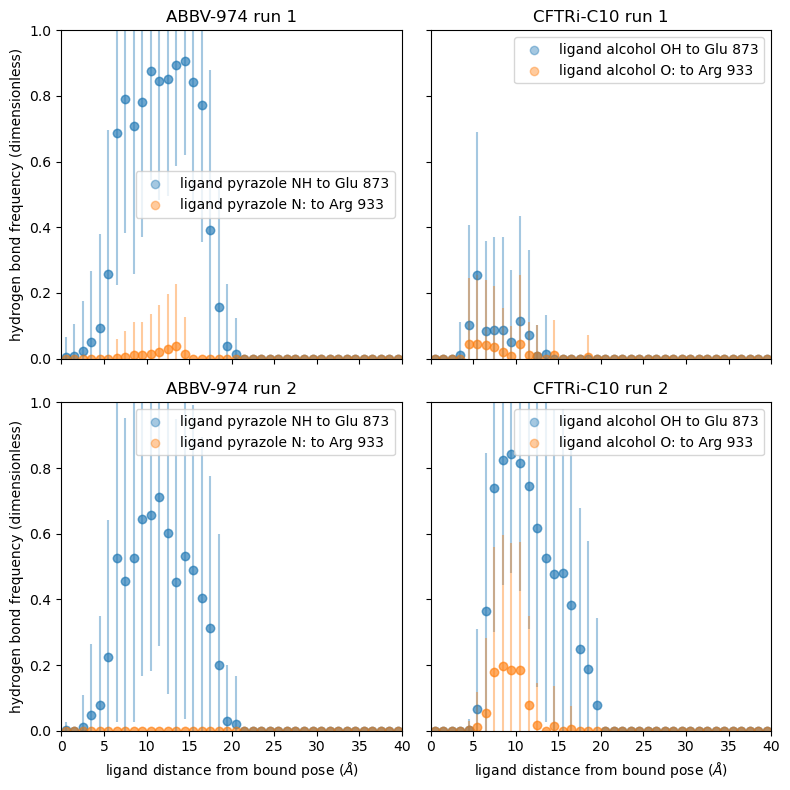

In [53]:

fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(8, 8))

dlabels = ["ligand pyrazole NH to Glu 873", "ligand alcohol OH to Glu 873"]
alabels = ["ligand pyrazole N: to Arg 933", "ligand alcohol O: to Arg 933"]

maxrounds = [2000,1000,2000,2000]
for run_ind in range(4):
    x = run_ind%2
    y = run_ind//2
    data_path = data_paths[run_ind]
    h5path = h5paths_names[run_ind][0]
    plot_to_subplot(data_path, h5path, maxrounds[run_ind], axs, (x,y), (dlabels[y], alabels[y]))

plt.tight_layout()
plt.savefig("/home/jonathan/Documents/grabelab/cftr/revisions/salt_bridge_hbonds.svg", format="svg", bbox_inches="tight")